<h1 style="text-align: center;"><b>Weather Type Classification

</b></h1>

<br>

**Nama**  : Ridho Sulistiono  
**NIM**   : 2304010035  
**Prodi** : D3 Statistika Terapan dan Komputasi  

---

### Deskripsi Dataset
Dataset ini merupakan data sintetis yang dirancang untuk mensimulasikan kondisi cuaca dan digunakan dalam tugas klasifikasi. Dataset ini mencakup sejumlah variabel yang merepresentasikan kondisi atmosfer dan lingkungan, serta mengelompokkan kondisi cuaca ke dalam empat kategori utama, yaitu Rainy, Sunny, Cloudy, dan Snowy sebagai variabel target.

Dataset ini dibuat untuk keperluan pembelajaran, khususnya dalam penerapan algoritma klasifikasi, preprocessing data, feature engineering, serta deteksi dan penanganan outlier. Dataset terdiri dari sejumlah fitur numerik dan kategorikal yang mencerminkan karakteristik cuaca dengan variasi nilai yang luas, termasuk nilai ekstrem yang sengaja disisipkan untuk meningkatkan kompleksitas analisis.

Berikut adalah fitur yang terdapat dalam dataset:
- **Temperature**: Suhu dalam derajat Celsius  
- **Humidity**: Persentase kelembapan udara  
- **Wind Speed**: Kecepatan angin dalam km/jam  
- **Precipitation (%)**: Persentase curah hujan  
- **Cloud Cover**: Kondisi tutupan awan  
- **Atmospheric Pressure**: Tekanan atmosfer dalam satuan hPa  
- **UV Index**: Indeks ultraviolet  
- **Season**: Musim saat data dicatat  
- **Visibility (km)**: Jarak pandang dalam kilometer  
- **Location**: Jenis lokasi pengambilan data  
- **Weather Type**: Jenis cuaca (Rainy, Sunny, Cloudy, Snowy) sebagai variabel target


**Sumber** = https://www.kaggle.com/datasets/nikhil7280/weather-type-classification

---

# Import Library

In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import joblib


from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, ConfusionMatrixDisplay

# Data Understanding

Membaca file CSV kemudian melakukan pengecekan awal untuk memahami struktur data sebelum preprocessing

In [60]:
df = pd.read_csv("weather_classification_data.csv")
df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB


Dataset terdiri dari **13.200 baris data** dan **11 fitur**. Seluruh kolom memiliki jumlah data **non-null sebanyak 13.200**, yang menunjukkan bahwa dataset tidak memiliki missing values sehingga tidak diperlukan penanganan data hilang.

Berdasarkan tipe datanya, dataset ini terdiri dari:
- **7 fitur numerik** (float64 dan int64), yaitu: Temperature, Humidity, Wind Speed, Precipitation (%), Atmospheric Pressure, UV Index, dan Visibility (km)  
- **4 fitur kategorikal** (object), yaitu: Cloud Cover, Season, Location, dan Weather Type  

Fitur **Weather Type** merupakan variabel target yang akan digunakan dalam proses klasifikasi, sedangkan fitur lainnya berperan sebagai variabel independen.

Secara umum, dataset ini sudah dalam kondisi bersih dari missing values, namun tetap memerlukan preprocessing lanjutan seperti encoding fitur kategorikal dan penanganan outlier pada fitur numerik sebelum digunakan dalam pemodelan machine learning.

In [62]:
# Cek missing values
df_temp_m = pd.DataFrame({
    'Jumlah Missing': df.isnull().sum(),
    'Persentase (%)': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Persentase (%)', ascending=False)

df_temp_m

,Jumlah Missing,Persentase (%)
Temperature,0,0.0
Humidity,0,0.0
Wind Speed,0,0.0
Precipitation (%),0,0.0
Cloud Cover,0,0.0
Atmospheric Pressure,0,0.0
UV Index,0,0.0
Season,0,0.0
Visibility (km),0,0.0
Location,0,0.0


Tidak ada missing values

In [63]:
# Cek duplikasi data
df.duplicated().sum()

np.int64(0)

Tidak ditemukan data duplikat dalam dataset

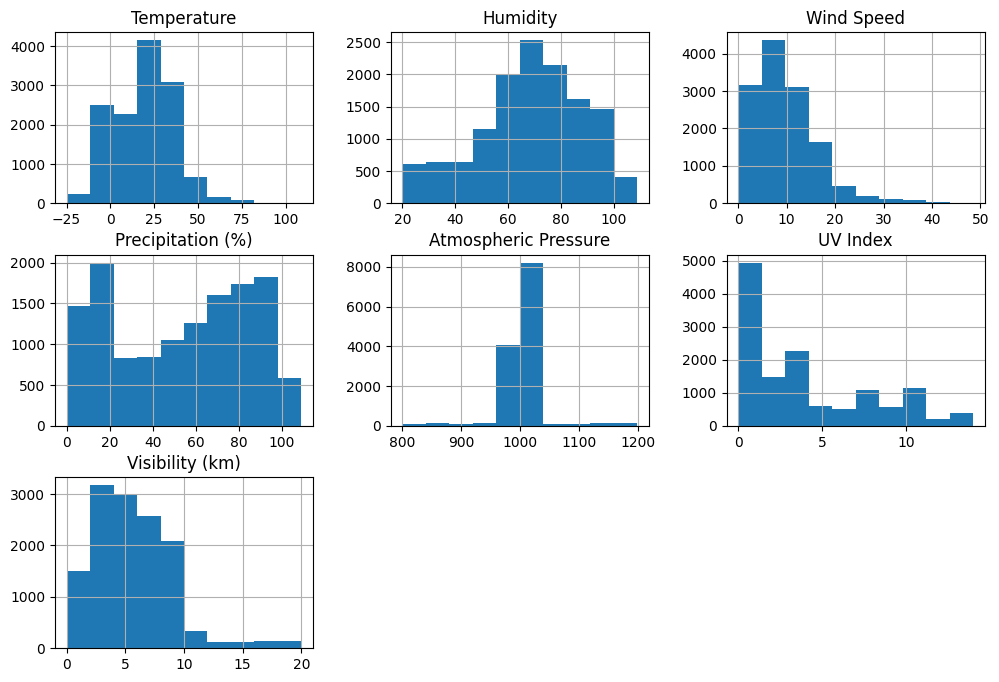

In [ ]:
# distribusi numerik
df.hist(figsize=(12,8))
plt.show()
     

Berdasarkan distribusi fitur numerik, terlihat bahwa setiap variabel memiliki pola yang berbeda-beda. Fitur seperti **Temperature dan Humidity cenderung memiliki distribusi yang lebih menyebar dan mendekati normal**, meskipun masih terdapat beberapa nilai ekstrem. Sementara itu,**Wind Speed, UV Index, dan Visibility menunjukkan distribusi yang condong ke kanan *(right-skewed)***, di mana sebagian besar nilai berada pada rentang rendah dengan beberapa nilai tinggi. Precipitation memiliki distribusi yang cukup luas dan bervariasi, menunjukkan kondisi curah hujan yang beragam. Di sisi lain, Atmospheric Pressure terlihat lebih terpusat di sekitar nilai tertentu, yang menandakan variasi yang relatif kecil dibandingkan fitur lainnya. Secara keseluruhan, perbedaan pola distribusi ini menunjukkan bahwa masing-masing fitur memiliki karakteristik unik yang dapat memberikan kontribusi berbeda dalam proses pemodelan.

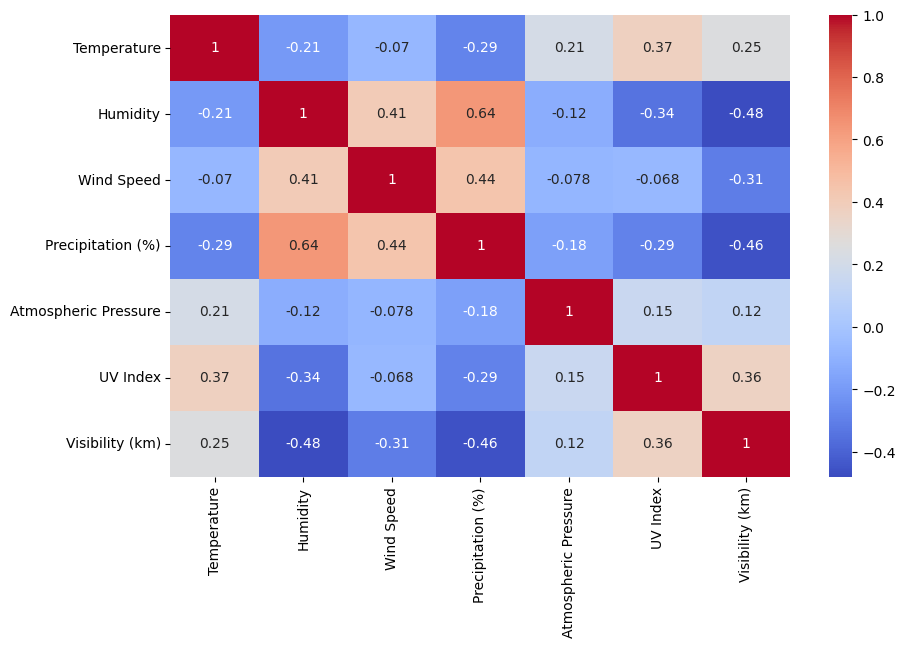

In [145]:
# corr heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

Berdasarkan heatmap korelasi, terlihat bahwa sebagian besar fitur memiliki hubungan yang tidak terlalu kuat, sehingga menunjukkan bahwa masing-masing variabel memberikan informasi yang cukup berbeda dalam model. Namun, terdapat beberapa korelasi yang cukup menonjol, seperti antara ****Humidity dan Precipitation yang memiliki korelasi positif cukup tinggi**, menunjukkan bahwa semakin tinggi kelembaban, semakin besar kemungkinan terjadi curah hujan. Selain itu, ****Humidity dan Visibility memiliki korelasi negatif yang cukup kuat**, yang mengindikasikan bahwa semakin tinggi kelembaban, jarak pandang cenderung menurun. Fitur Wind Speed juga memiliki hubungan moderat dengan Precipitation, sementara Temperature menunjukkan korelasi positif dengan UV Index dan Visibility. Secara keseluruhan, tidak terdapat korelasi yang terlalu tinggi antar fitur, sehingga risiko multikolinearitas relatif rendah dan seluruh fitur masih relevan untuk digunakan dalam pemodelan.

In [150]:
# Cek unique values pada kolom kategorikal
cat_cols = df.select_dtypes(include='object').columns

summary = []

for col in cat_cols:
    unique_vals = df[col].dropna().unique().tolist()
    
    if len(unique_vals) > 5:
        sample = ", ".join(map(str, unique_vals[:3])) + ", ..."
    else:
        sample = ", ".join(map(str, unique_vals))
    
    summary.append({
        'Fitur': col,
        'Jumlah Kategori': len(unique_vals),
        'Deskripsi': sample
    })

unique_summary = pd.DataFrame(summary).sort_values('Jumlah Kategori', ascending=False)

unique_summary

,Fitur,Jumlah Kategori,Deskripsi
0,Cloud Cover,4,"partly cloudy, clear, overcast, cloudy"
1,Season,4,"Winter, Spring, Summer, Autumn"
3,Weather Type,4,"Rainy, Cloudy, Sunny, Snowy"
2,Location,3,"inland, mountain, coastal"


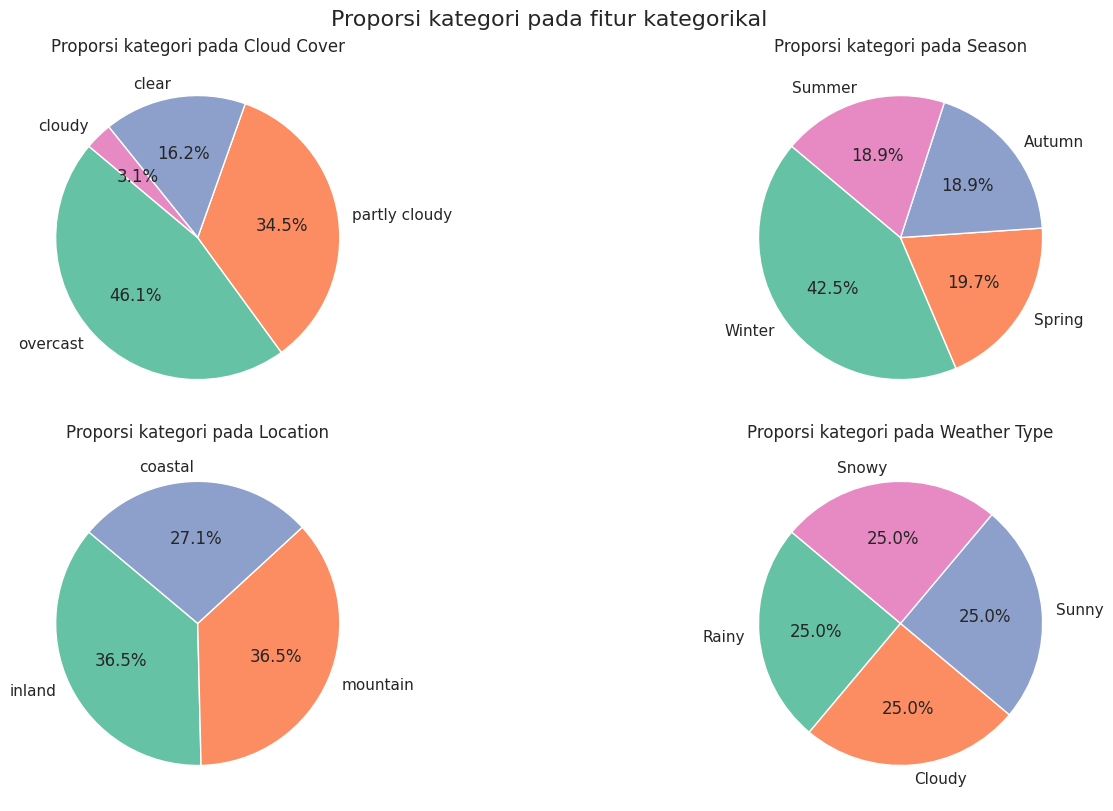

In [156]:
# proporsi kategori pada fitur kategorikal
n = len(cat_cols)
cols = 2
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows), constrained_layout=True)

axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    counts = df[col].value_counts()

    colors = sns.color_palette("Set2", n_colors=len(counts))

    # Plot
    ax.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140, colors=colors)
    ax.set_title(f'Proporsi kategori pada {col}')

for ax in axes[len(cat_cols):]:
    ax.axis('off')

fig.suptitle('Proporsi kategori pada fitur kategorikal', fontsize=16)
plt.show()

Berdasarkan visualisasi proporsi fitur kategorikal, terlihat bahwa distribusi pada setiap fitur memiliki karakteristik yang berbeda. Pada fitur Cloud Cover, kategori *overcast* mendominasi dibandingkan kategori lainnya, diikuti oleh *partly cloudy*, sementara *cloudy* memiliki proporsi paling kecil. 

Pada fitur Season, distribusi relatif cukup seimbang meskipun *Winter* memiliki proporsi sedikit lebih tinggi dibandingkan musim lainnya. Fitur Location juga menunjukkan distribusi yang cukup merata antara *inland* dan *mountain*, dengan *coastal* sedikit lebih rendah.

Sementara itu, untuk variabel target Weather Type, seluruh kategori (*Cloudy, Rainy, Snowy, Sunny*) memiliki proporsi yang sama, yang menunjukkan bahwa dataset dalam kondisi seimbang (balanced) untuk proses klasifikasi.

# Preprocessing

## Salin Data

Menyalin dataset dilakukan untuk menjaga data asli tetap utuh sebagai referensi. Dengan demikian, setiap proses preprocessing dilakukan pada salinan data sehingga tidak memengaruhi data mentah.

In [66]:
df_p = df.copy()

## Outlier

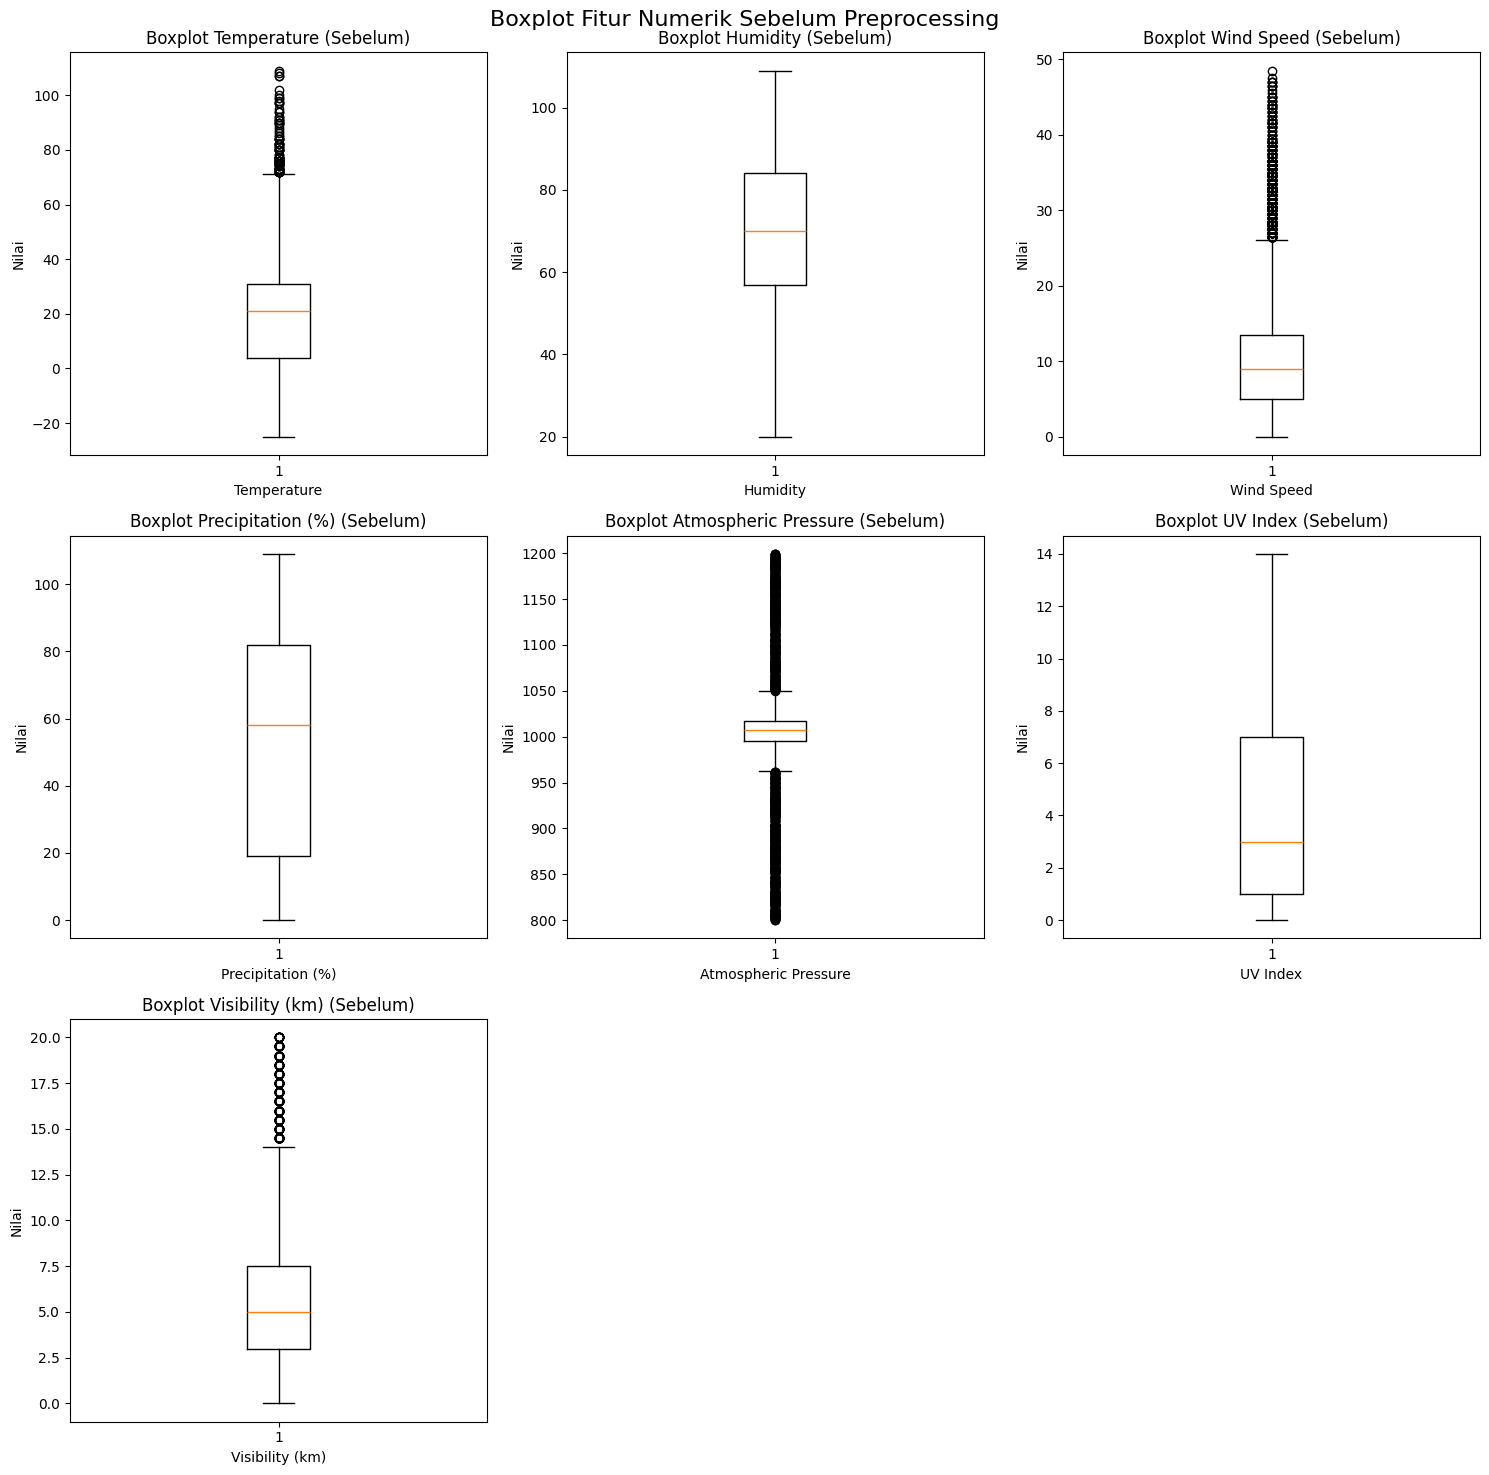

In [67]:
numeric_columns = df_p.select_dtypes(include=['float64', 'int64']).columns

n = len(numeric_columns)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    axes[i].boxplot(df_p[col])
    axes[i].set_title(f'Boxplot {col} (Sebelum)')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Nilai')

# hide subplot kosong
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Boxplot Fitur Numerik Sebelum Preprocessing', fontsize=16)
plt.tight_layout()
plt.show()

Berdasarkan visualisasi boxplot pada fitur numerik, terlihat bahwa beberapa variabel memiliki distribusi data yang cukup lebar serta mengandung outlier.

Fitur seperti **Temperature**, **Wind Speed**, **Visibility (km)**, dan **Atmospheric Pressure** menunjukkan adanya banyak nilai ekstrem (outlier), baik pada sisi atas maupun bawah distribusi. Hal ini sesuai dengan karakteristik dataset yang memang mengandung nilai tidak realistis.

Fitur **Precipitation (%)** dan **Humidity** memiliki sebaran yang relatif lebih stabil, meskipun tetap terdapat beberapa nilai ekstrem. Sementara itu, **UV Index** menunjukkan distribusi yang lebih terkonsentrasi dengan sedikit atau tanpa outlier signifikan.

Secara keseluruhan, keberadaan outlier pada beberapa fitur numerik menunjukkan perlunya dilakukan penanganan lebih lanjut, seperti metode capping atau transformasi data.

In [68]:
outlier_report = []

numeric_cols = df_p.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_cols:
    lower = df_p[col].quantile(0.01)
    upper = df_p[col].quantile(0.99)
    
    n_out = ((df_p[col] < lower) | (df_p[col] > upper)).sum()
    
    # capping
    df_p[col] = df_p[col].clip(lower=lower, upper=upper)
    
    outlier_report.append({
        'Kolom': col,
        'Outlier Ditangani': int(n_out),
        'Batas Bawah (P1)': round(lower, 2),
        'Batas Atas (P99)': round(upper, 2)
    })

report_df = pd.DataFrame(outlier_report)
print(report_df)

                  Kolom  Outlier Ditangani  Batas Bawah (P1)  Batas Atas (P99)
0           Temperature                245            -16.00             66.01
1              Humidity                163             21.00            107.00
2            Wind Speed                130              0.00             34.50
3     Precipitation (%)                216              1.00            107.00
4  Atmospheric Pressure                264            843.88           1160.85
5              UV Index                  0              0.00             14.00
6       Visibility (km)                131              0.50             18.00


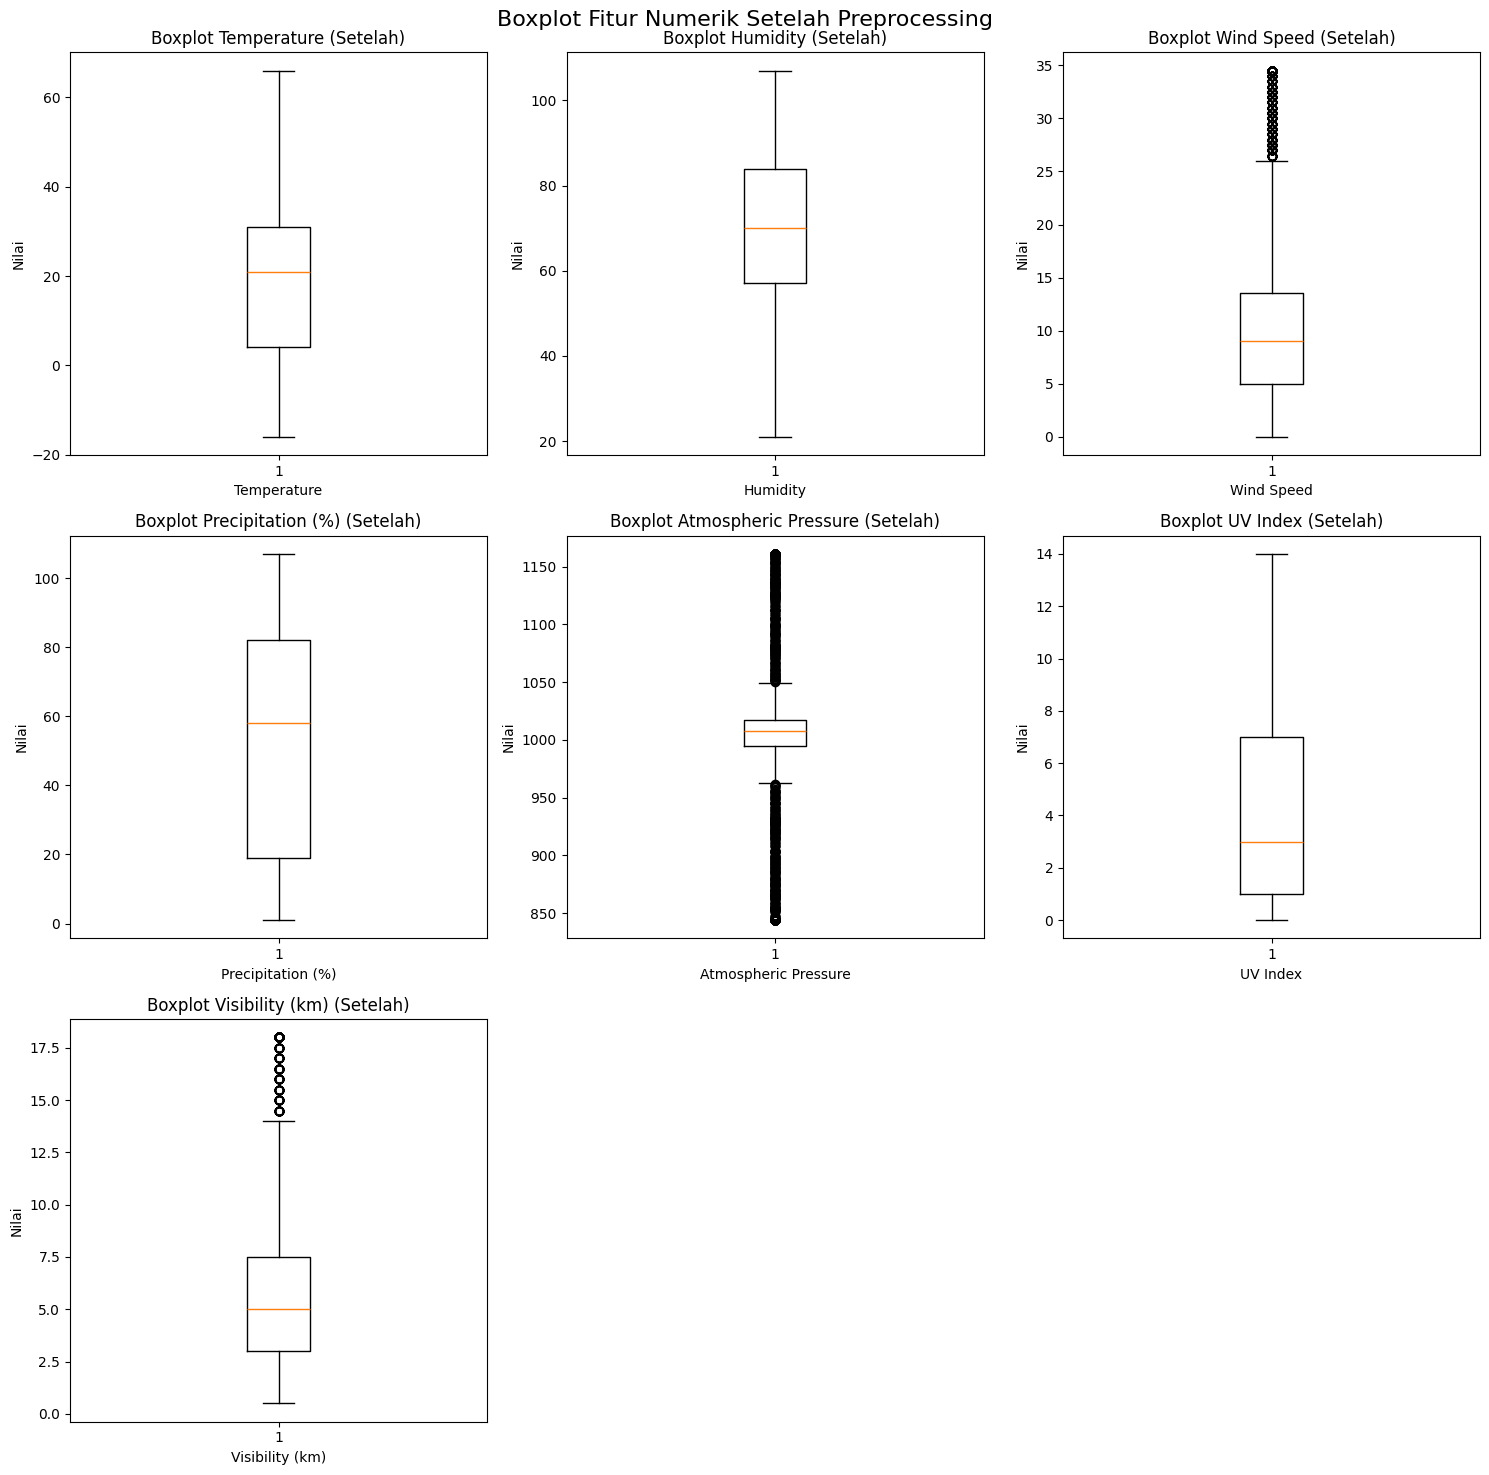

In [69]:
numeric_columns = df_p.select_dtypes(include=['float64', 'int64']).columns

n = len(numeric_columns)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    axes[i].boxplot(df_p[col])
    axes[i].set_title(f'Boxplot {col} (Setelah)')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Nilai')

# hide subplot kosong
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Boxplot Fitur Numerik Setelah Preprocessing', fontsize=16)
plt.tight_layout()
plt.show()

Metode penanganan outlier yang digunakan adalah **percentile capping** dengan batas persentil ke-1 (P1) dan ke-99 (P99). Metode ini bekerja dengan menentukan nilai ambang bawah dan atas berdasarkan distribusi data, yaitu nilai pada persentil ke-1 sebagai batas bawah dan persentil ke-99 sebagai batas atas.

Nilai yang berada di bawah batas bawah akan digantikan dengan nilai P1, sedangkan nilai yang berada di atas batas atas akan digantikan dengan nilai P99. Dengan demikian, nilai ekstrem tidak dihapus, melainkan dibatasi agar tidak memberikan pengaruh berlebihan terhadap distribusi data dan proses pemodelan.

## Membagi Data

Setelah dataset hasil preprocessing disimpan, dilakukan pembagian data menjadi data training dan testing dengan rasio 80:20. Pembagian ini bertujuan untuk melatih model menggunakan data training serta mengevaluasi performa model pada data testing.

In [70]:
X = df_p.drop('Weather Type', axis=1)
y = df_p['Weather Type']

# encode target
le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (10560, 10)
Test : (2640, 10)


## Encoding Kolom Kategorikal

Fitur kategorikal dikonversi menjadi bentuk numerik agar dapat digunakan dalam proses analisis dan pemodelan. Metode yang digunakan adalah *one-hot encoding*. Metode ini dipilih karena variabel kategorikal dalam dataset tidak memiliki hubungan urutan antar kategori. Dengan demikian, *one-hot encoding* mampu merepresentasikan setiap kategori secara independen tanpa mengasumsikan hubungan numerik yang tidak relevan.

In [71]:
cat_cols = ['Cloud Cover', 'Season', 'Location']
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_cat = encoder.fit_transform(X_train[cat_cols])
X_test_cat = encoder.transform(X_test[cat_cols])

## Scaling Fitur Numerik

Feature scaling dilakukan karena setiap fitur memiliki rentang nilai yang berbeda, sehingga dapat memengaruhi performa model, khususnya pada algoritma berbasis linear seperti Logistic Regression.

Untuk mengatasi hal tersebut, digunakan metode StandardScaler yang menstandardisasi data sehingga memiliki rata-rata 0 dan standar deviasi 1, sehingga seluruh fitur berada pada skala yang sebanding.

Proses scaling dilakukan dengan melakukan *fit* pada data training dan *transform* pada data testing guna menghindari data leakage.

In [72]:
scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train[num_cols])
X_test_num = scaler.transform(X_test[num_cols])

## Data Setelah Preprocessing

In [73]:
X_train_final = np.hstack([X_train_num, X_train_cat])
X_test_final = np.hstack([X_test_num, X_test_cat])

print("Train shape:", X_train_final.shape)
print("Test shape :", X_test_final.shape)

Train shape: (10560, 18)
Test shape : (2640, 18)


In [74]:
# kolom hasil encoding
encoded_cols = encoder.get_feature_names_out(cat_cols)

# gabungkan nama kolom
all_cols = list(num_cols) + list(encoded_cols)

# >dataframe
X_train_df = pd.DataFrame(X_train_final, columns=all_cols)
X_test_df = pd.DataFrame(X_test_final, columns=all_cols)

X_train_df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km),Cloud Cover_clear,Cloud Cover_cloudy,Cloud Cover_overcast,Cloud Cover_partly cloudy,Season_Autumn,Season_Spring,Season_Summer,Season_Winter,Location_coastal,Location_inland,Location_mountain
0,-1.541020,0.071797,-1.245907,0.575536,-0.463688,-0.778137,-1.033026,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,-1.244456,-0.424718,0.548332,0.669390,-0.223243,-0.778137,-0.286413,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,-1.066518,1.313085,-0.872107,1.357652,-0.511439,-1.037426,-0.734381,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,0.060425,-0.474370,0.025012,-1.176402,0.265843,1.555463,1.206811,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.594240,-1.814961,-1.021627,-1.207687,0.181079,1.814752,0.161554,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [75]:
X_train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10560 entries, 0 to 10559
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Temperature                10560 non-null  float64
 1   Humidity                   10560 non-null  float64
 2   Wind Speed                 10560 non-null  float64
 3   Precipitation (%)          10560 non-null  float64
 4   Atmospheric Pressure       10560 non-null  float64
 5   UV Index                   10560 non-null  float64
 6   Visibility (km)            10560 non-null  float64
 7   Cloud Cover_clear          10560 non-null  float64
 8   Cloud Cover_cloudy         10560 non-null  float64
 9   Cloud Cover_overcast       10560 non-null  float64
 10  Cloud Cover_partly cloudy  10560 non-null  float64
 11  Season_Autumn              10560 non-null  float64
 12  Season_Spring              10560 non-null  float64
 13  Season_Summer              10560 non-null  flo

**Setelah Preprocessing (Data Latih):**
- Jumlah data menjadi 10.560 (80% dari dataset)  
- Jumlah fitur meningkat menjadi 18 kolom  
- Fitur kategorikal diubah menjadi numerik menggunakan One-Hot Encoding  
- Fitur numerik distandardisasi menggunakan StandardScaler  
- Seluruh data telah berbentuk numerik dan tidak memiliki missing values

In [76]:
X_test_df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km),Cloud Cover_clear,Cloud Cover_cloudy,Cloud Cover_overcast,Cloud Cover_partly cloudy,Season_Autumn,Season_Spring,Season_Summer,Season_Winter,Location_coastal,Location_inland,Location_mountain
0,0.416301,0.171100,-0.124508,0.481682,-0.263081,-0.259559,-0.435736,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0.712865,0.121449,0.473572,-0.237864,-0.009356,-0.259559,0.012231,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
2,1.128054,-0.871582,-1.395427,-1.645672,0.298053,1.814752,-0.137091,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,-0.117514,0.667616,0.996891,0.450398,-0.016702,-1.037426,-1.033026,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,1.602556,1.660646,-0.274028,1.607929,0.306812,-0.000270,1.505456,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [77]:
X_test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Temperature                2640 non-null   float64
 1   Humidity                   2640 non-null   float64
 2   Wind Speed                 2640 non-null   float64
 3   Precipitation (%)          2640 non-null   float64
 4   Atmospheric Pressure       2640 non-null   float64
 5   UV Index                   2640 non-null   float64
 6   Visibility (km)            2640 non-null   float64
 7   Cloud Cover_clear          2640 non-null   float64
 8   Cloud Cover_cloudy         2640 non-null   float64
 9   Cloud Cover_overcast       2640 non-null   float64
 10  Cloud Cover_partly cloudy  2640 non-null   float64
 11  Season_Autumn              2640 non-null   float64
 12  Season_Spring              2640 non-null   float64
 13  Season_Summer              2640 non-null   float

**Setelah Preprocessing (Data Uji):**
- Jumlah data menjadi 2.640 (20% dari dataset)  
- Jumlah fitur tetap 18 kolom (konsisten dengan data latih)  
- Fitur kategorikal telah dikonversi menjadi numerik menggunakan One-Hot Encoding (mengikuti hasil dari data latih)  
- Fitur numerik telah ditransformasi menggunakan StandardScaler berdasarkan parameter dari data latih  
- Seluruh data telah berbentuk numerik dan tidak memiliki missing values  

# Modeling

## Seach Domain Bayesian Optimization

Bayesian Optimization merupakan metode optimasi hiperparameter yang menggunakan model probabilistik, seperti Gaussian Process, untuk memodelkan fungsi objektif. Metode ini memilih kombinasi parameter secara adaptif berdasarkan informasi dari iterasi sebelumnya melalui acquisition function. Dengan pendekatan tersebut, pencarian parameter menjadi lebih efisien dibandingkan Grid Search atau Random Search.

In [133]:
# base model
base_models = {
    'LogReg': LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(
        random_state=42,
        eval_metric='mlogloss',
        objective='multi:softprob'
    ),
    'SVM': SVC(probability=True, random_state=42)
}

# parameter
search_domain = {
    'LogReg': {
        'C': Real(1e-3, 10, prior='log-uniform'),
        'solver': Categorical(['lbfgs', 'saga'])
    },
    'Random Forest': {
        'n_estimators': Integer(100, 300),
        'max_depth': Integer(5, 20),
        'min_samples_split': Integer(2, 10),
        'min_samples_leaf': Integer(1, 5)
    },
    'XGBoost': {
        'n_estimators': Integer(100, 300),
        'learning_rate': Real(0.01, 0.2, prior='log-uniform'),
        'max_depth': Integer(3, 8),
        'subsample': Real(0.7, 1.0),
        'colsample_bytree': Real(0.7, 1.0)
    },
    'SVM': {
        'C': Real(1e-3, 10, prior='log-uniform'),
        'kernel': Categorical(['linear', 'rbf'])
    }
}

## Training 

Setiap model dioptimasi menggunakan **BayesSearchCV** dengan konfigurasi sebagai berikut:

- **n_iter = 30**, jumlah iterasi pencarian hiperparameter untuk setiap model  
- **Stratified K-Fold (cv = 3)**, validasi silang yang mempertahankan proporsi distribusi kelas  
- **Scoring = Accuracy**, metrik utama yang digunakan dalam proses optimasi  
- **Evaluasi tambahan menggunakan F1-score (macro)**, untuk mengukur keseimbangan performa antar kelas

In [134]:
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

best_models = {}
best_params = {}
results_list = []

for name, base_model in base_models.items():
    print(f'\n{"-"*40}')
    print(f'  Optimasi: {name}')
    print(f'{"-"*40}')

    bayes_search = BayesSearchCV(
        estimator=base_model,
        search_spaces=search_domain[name],
        n_iter=30,
        cv=cv_strategy,
        scoring='accuracy',
        n_jobs=-1,
        random_state=42
    )

    bayes_search.fit(X_train_final, y_train)

    best_model = bayes_search.best_estimator_
    best_models[name] = best_model
    best_params[name] = bayes_search.best_params_

    # evaluasi test
    y_pred = best_model.predict(X_test_final)

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='macro')

    results_list.append({
        'Model'      : name,
        'Best CV Acc': round(bayes_search.best_score_, 4),
        'Test Acc'   : round(acc, 4),
        'F1 Score'   : round(f1, 4)
    })

    print(f'Best CV Accuracy : {bayes_search.best_score_:.4f}')
    print(f'Test Accuracy    : {acc:.4f}')
    print(f'F1 Score         : {f1:.4f}')
    print(f'Best Params      : {dict(bayes_search.best_params_)}')

print('\nOptimasi model selesai.')


----------------------------------------
  Optimasi: LogReg
----------------------------------------
Best CV Accuracy : 0.8714
Test Accuracy    : 0.8693
F1 Score         : 0.8695
Best Params      : {'C': 10.0, 'solver': 'saga'}

----------------------------------------
  Optimasi: Random Forest
----------------------------------------
Best CV Accuracy : 0.9153
Test Accuracy    : 0.9140
F1 Score         : 0.9144
Best Params      : {'max_depth': 19, 'min_samples_leaf': 4, 'min_samples_split': 9, 'n_estimators': 183}

----------------------------------------
  Optimasi: XGBoost
----------------------------------------
Best CV Accuracy : 0.9129
Test Accuracy    : 0.9140
F1 Score         : 0.9143
Best Params      : {'colsample_bytree': 0.9608350981733038, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 226, 'subsample': 0.7}

----------------------------------------
  Optimasi: SVM
----------------------------------------
Best CV Accuracy : 0.9093
Test Accuracy    : 0.9091
F1 Score  

Model Random Forest dan XGBoost menunjukkan performa terbaik dengan akurasi dan F1-score sekitar 91.4%, serta memiliki kemampuan generalisasi yang baik karena nilai cross-validation yang konsisten dengan hasil pada data uji. Sementara itu, model SVM juga memberikan performa yang kompetitif, meskipun masih sedikit di bawah kedua model tersebut. Di sisi lain, Logistic Regression memiliki performa paling rendah, yang mengindikasikan bahwa pola dalam data bersifat non-linear dan kurang dapat ditangkap oleh model linear.

## Perbandingan Model

In [136]:
results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values(by='Test Acc', ascending=False)

print(results_df)
print(f'\nModel terbaik: {results_df.iloc[0]["Model"]}')

           Model  Best CV Acc  Test Acc  F1 Score
1  Random Forest       0.9153    0.9140    0.9144
2        XGBoost       0.9129    0.9140    0.9143
3            SVM       0.9093    0.9091    0.9094
0         LogReg       0.8714    0.8693    0.8695

Model terbaik: Random Forest


Berdasarkan hasil evaluasi, model Random Forest dan XGBoost menunjukkan performa terbaik dengan nilai akurasi dan F1-score yang hampir identik (~91.4%), serta memiliki konsistensi antara hasil cross-validation dan data uji yang menandakan kemampuan generalisasi yang baik. 

Model SVM juga menunjukkan performa yang cukup tinggi (~90.9%), namun masih berada di bawah kedua model tersebut. Sementara itu, Logistic Regression memiliki performa paling rendah (~86.9%), yang mengindikasikan bahwa hubungan antar fitur dalam dataset bersifat non-linear dan lebih efektif ditangani oleh model berbasis tree atau kernel.


----------------------------------------
Classification Report — LogReg
----------------------------------------
              precision    recall  f1-score   support

      Cloudy       0.82      0.84      0.83       660
       Rainy       0.85      0.86      0.85       660
       Snowy       0.89      0.92      0.90       660
       Sunny       0.92      0.87      0.89       660

    accuracy                           0.87      2640
   macro avg       0.87      0.87      0.87      2640
weighted avg       0.87      0.87      0.87      2640


----------------------------------------
Classification Report — Random Forest
----------------------------------------
              precision    recall  f1-score   support

      Cloudy       0.86      0.93      0.89       660
       Rainy       0.91      0.91      0.91       660
       Snowy       0.95      0.90      0.93       660
       Sunny       0.95      0.92      0.93       660

    accuracy                           0.91      2640
   m

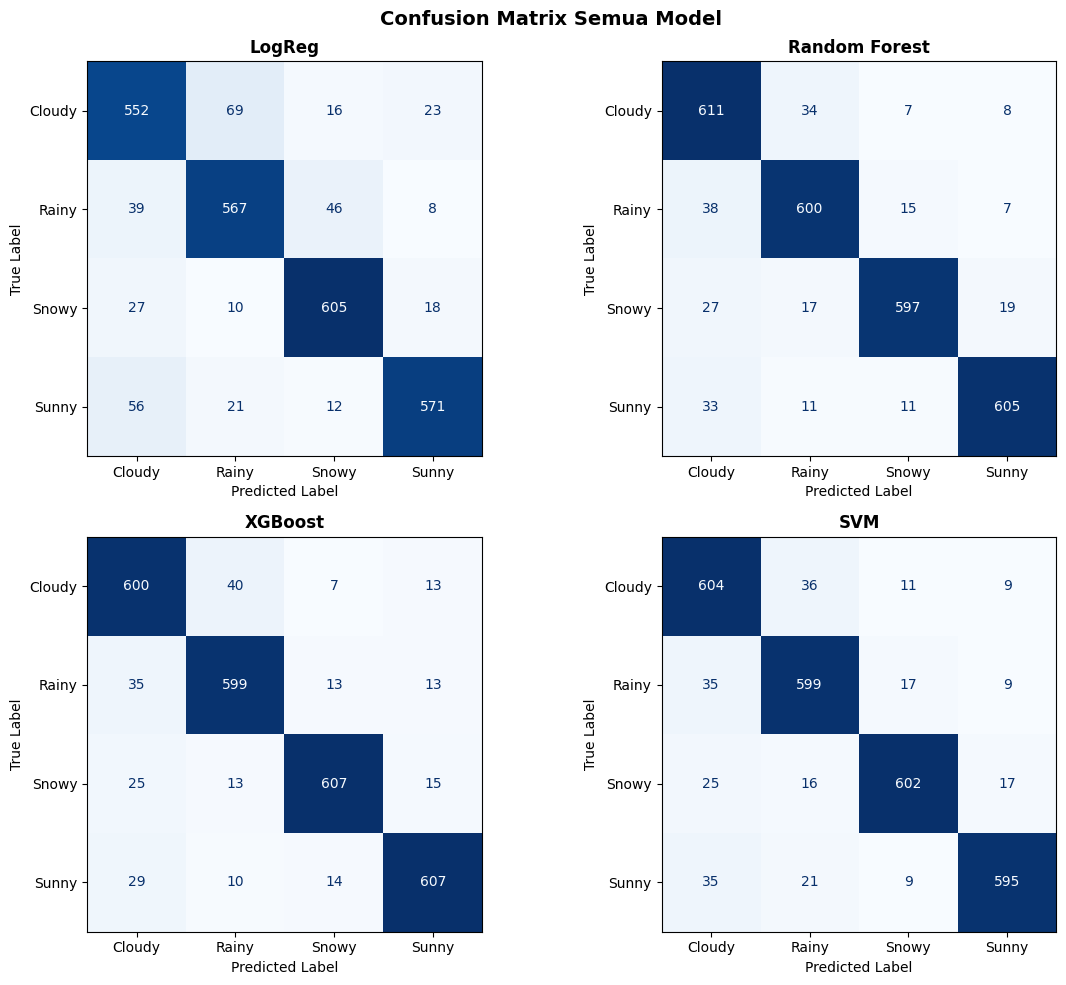

In [ ]:
# label asli
class_names = ['Cloudy', 'Rainy', 'Snowy', 'Sunny']

# setup plot
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(best_models.items()):

    y_pred = model.predict(X_test_final)

    # print classification report
    print(f'\n{"-"*40}')
    print(f'Classification Report — {name}')
    print(f'{"-"*40}')
    print(classification_report(y_test, y_pred, target_names=class_names))

    # plot confusion matrix
    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test_final,
        y_test,
        display_labels=class_names,
        cmap='Blues',
        ax=axes[i],
        colorbar=False
    )
    
    axes[i].set_title(f'{name}', fontweight='bold')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.suptitle('Confusion Matrix Semua Model', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

Berdasarkan confusion matrix, semua model sudah mampu mengklasifikasikan data dengan cukup baik karena sebagian besar prediksi berada pada bagian diagonal (prediksi benar). Model Random Forest dan XGBoost terlihat paling stabil karena jumlah kesalahan prediksinya lebih sedikit dibandingkan model lainnya.

Kesalahan yang paling sering terjadi adalah antara kelas **Cloudy** dan **Rainy**, yang menunjukkan bahwa kedua kondisi cuaca ini memiliki karakteristik yang mirip sehingga cukup sulit dibedakan oleh model. Selain itu, kelas **Sunny** juga kadang tertukar dengan **Cloudy**.

Secara umum, model berbasis tree seperti Random Forest dan XGBoost lebih mampu mengenali pola data dengan baik, terutama untuk membedakan kondisi cuaca yang memiliki kemiripan.

## Feature Importance

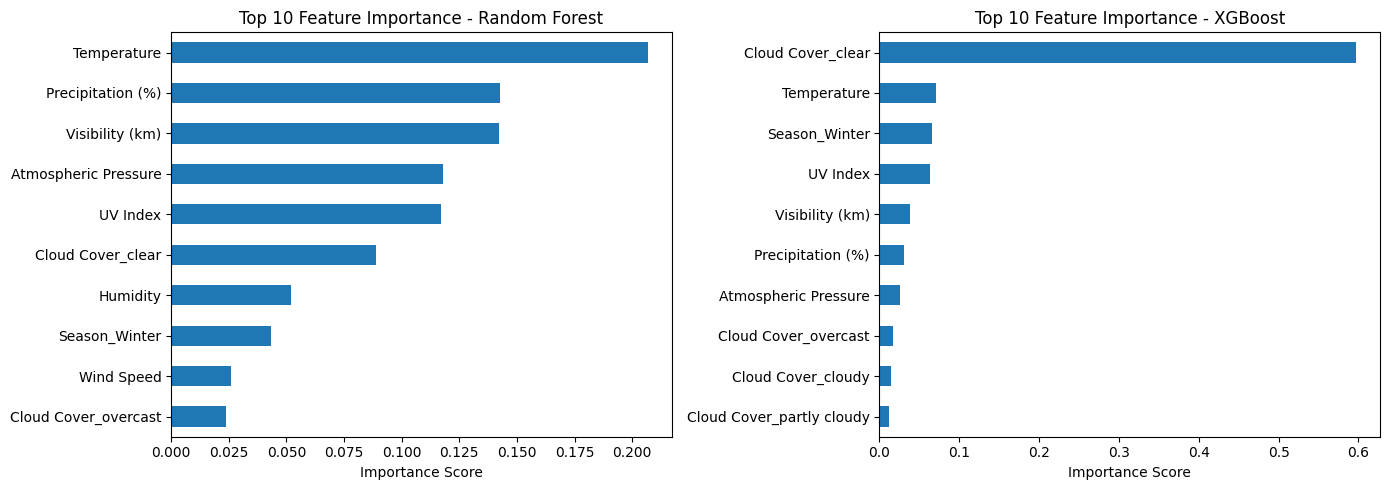

In [143]:
feature_names = X_train_df.columns
models_to_plot = ['Random Forest', 'XGBoost']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name in zip(axes, models_to_plot):
    model = best_models[name]
    importances = pd.Series(model.feature_importances_, index=feature_names)
    top10 = importances.sort_values(ascending=True).tail(10)

    top10.plot(kind='barh', ax=ax)
    ax.set_title(f'Top 10 Feature Importance - {name}')
    ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

- Berdasarkan hasil feature importance, terlihat bahwa setiap model memiliki pendekatan yang berbeda dalam menentukan prediksi. Pada model Random Forest, fitur seperti Temperature, Precipitation, dan Visibility menjadi faktor paling dominan, yang menunjukkan bahwa model ini lebih mengandalkan kondisi fisik dan variabel numerik dalam membedakan jenis cuaca.

- Pada model XGBoost, fitur Cloud Cover_clear memiliki pengaruh yang sangat besar dibandingkan fitur lainnya. Hal ini mengindikasikan bahwa model sangat bergantung pada kondisi langit (cerah atau tidak), sehingga fitur kategorikal hasil encoding memiliki peran penting dalam proses klasifikasi. Selain itu, fitur seperti Season dan UV Index juga mulai berkontribusi pada XGBoost, meskipun tidak sebesar Cloud Cover, yang menunjukkan bahwa model ini mampu menangkap kombinasi pola yang lebih spesifik dari beberapa fitur sekaligus.

- Perbedaan ini menunjukkan bahwa setiap model memiliki cara yang berbeda dalam memahami pola data: Random Forest lebih fokus pada hubungan umum antar variabel numerik, sedangkan XGBoost lebih sensitif terhadap pola spesifik dari fitur kategorikal. Meskipun demikian, keduanya tetap menghasilkan performa yang hampir sama, sehingga perbedaan ini lebih mencerminkan cara kerja model daripada perbedaan kualitas hasil.

## Simpan Model Terbaik

Model terbaik disimpan menggunakan library *joblib* bersama dengan objek preprocessing berupa StandardScaler. Hal ini dilakukan untuk memastikan bahwa data baru yang digunakan saat prediksi dapat melalui proses transformasi yang sama seperti data pelatihan, sehingga menjaga konsistensi dan akurasi hasil prediksi.

In [158]:
# save model
joblib.dump((best_models['Random Forest'], scaler), 'model_pipeline.pkl')

# load model
# model, scaler = joblib.load('model_pipeline.pkl')

['model_pipeline.pkl']

---

## Kesimpulan

- Model machine learning yang dibangun mampu mengklasifikasikan tipe cuaca dengan baik, ditunjukkan oleh nilai akurasi dan F1-score yang tinggi serta konsistensi antara hasil cross-validation dan data uji.  

- Model Random Forest dan XGBoost menunjukkan performa terbaik dengan hasil yang hampir identik, menandakan keduanya efektif dalam menangkap pola data yang kompleks.  

- Logistic Regression memiliki performa paling rendah, yang menunjukkan keterbatasan model linear dalam menangani hubungan non-linear pada data.  

- Kesalahan klasifikasi paling sering terjadi pada kelas yang memiliki karakteristik mirip, seperti Cloudy dan Rainy.  

- Fitur-fitur seperti Temperature, Precipitation, dan Cloud Cover memiliki pengaruh besar dalam proses klasifikasi berdasarkan hasil feature importance.  

- Secara keseluruhan, pendekatan machine learning terbukti efektif untuk permasalahan klasifikasi tipe cuaca multi-kelas dengan performa yang baik dan stabil.